# LADI-v2 Multi-Seed Hybrid Dynamic GCN++ EfficientNet-B0 Notebook — P100 Time-Optimised Version

This Kaggle P100 notebook trains the **Final Hybrid Dynamic GCN++ + EfficientNet-B0** model with **three random seeds** and then builds an **ensemble** by averaging calibrated probabilities across seeds.

This version follows the runtime-efficient final plan:

- `SEEDS = [42, 123, 2024]`
- `NUM_EPOCHS = 8` per seed
- `IMAGE_SIZE = 288` for faster P100 training
- `BATCH_SIZE = 12`
- `GRAD_ACCUM_STEPS = 1`
- validation every 2 epochs instead of every epoch
- one shared PMI graph scan/cache reused across all seeds
- test evaluation only after the best checkpoint for each seed
- final plots only after all seed/ensemble results are produced

Scientific purpose:

- answer the supervisor's random-seed concern;
- report mean ± standard deviation across seeds;
- test whether a probability ensemble gives a more reliable Dynamic GCN++ result.


In [1]:
# ============================================================
# 0. Stable Kaggle P100 CUDA Environment Setup
# ============================================================
# Purpose:
# - Force a CUDA-compatible PyTorch build for Tesla P100.
# - Keep Hugging Face/cache files out of /kaggle/working.
# - Avoid Kaggle CPU fallback by checking CUDA later.
#
# IMPORTANT:
# After this cell installs packages, it will restart the kernel once.
# Then run the notebook again from the first cell.

import os
import sys
import subprocess
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Keep all temporary/cache files outside Kaggle output space.
os.environ["HF_HOME"] = "/kaggle/temp/hf_home"
os.environ["HF_DATASETS_CACHE"] = "/kaggle/temp/hf_datasets"
os.environ["HF_HUB_CACHE"] = "/kaggle/temp/hf_hub"
os.environ["TRANSFORMERS_CACHE"] = "/kaggle/temp/transformers"
os.environ["TMPDIR"] = "/kaggle/temp"

for p in [
    os.environ["HF_HOME"],
    os.environ["HF_DATASETS_CACHE"],
    os.environ["HF_HUB_CACHE"],
    os.environ["TRANSFORMERS_CACHE"],
    os.environ["TMPDIR"],
]:
    Path(p).mkdir(parents=True, exist_ok=True)

# New marker name so this optimized version does not reuse an old broken/CPU environment marker.
ENV_MARKER = Path("/kaggle/temp/ladi_v2_dynamic_gcn_p100_cuda_regcal_env_v3")

if not ENV_MARKER.exists():
    print("Installing stable Kaggle P100 CUDA environment. This may take a few minutes...")

    # Clear pip cache to protect Kaggle disk.
    subprocess.run([sys.executable, "-m", "pip", "cache", "purge"], check=False)

    base_packages = [
        "numpy==1.26.4",
        "scipy==1.13.1",
        "pandas==2.2.2",
        "scikit-learn==1.5.2",
        "pillow==10.4.0",
        "tqdm==4.66.5",
        "matplotlib==3.9.2",
        "datasets==2.21.0",
        "huggingface_hub==0.24.7",
    ]
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
        *base_packages
    ])
    # CUDA 11.8 PyTorch is safer for Tesla P100 than some newer Kaggle builds.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
        "torch==2.4.1", "torchvision==0.19.1",
        "--index-url", "https://download.pytorch.org/whl/cu118"
    ])

    ENV_MARKER.write_text("ready")
    print("\nEnvironment installed. Restarting kernel now.")
    print("After restart, run this notebook again from the first cell.")

    import IPython
    IPython.Application.instance().kernel.do_shutdown(True)
else:
    print("Stable P100 CUDA environment marker found. Skipping installation.")


Stable P100 CUDA environment marker found. Skipping installation.


In [2]:
# ============================================================
# 1. Imports, Version Check, and Mandatory CUDA Sanity Check
# ============================================================

import os
import io
import gc
import sys
import json
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)

from datasets import load_dataset
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")

# ============================================================
# Mandatory CUDA check
# ============================================================

REQUIRE_CUDA = True

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. In Kaggle, set Accelerator = GPU P100, "
        "then Factory reset runtime and run from the first cell again. "
        "Do not continue on CPU for this Dynamic GCN notebook."
    )

if torch.cuda.is_available():
    torch.cuda.set_device(0)

    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)

    print("GPU:", gpu_name)
    print("Compute capability:", gpu_capability)

    # CUDA forward/backward sanity check
    # requires_grad=True is necessary because we call backward().
    x = torch.randn(128, 128, device="cuda", requires_grad=True)
    y = (x @ x).mean()
    y.backward()

    torch.cuda.synchronize()
    del x, y
    torch.cuda.empty_cache()

    print("CUDA forward/backward sanity check passed.")
else:
    print("WARNING: CUDA is not available. Training will be slow on CPU.")

# ============================================================
# P100-friendly speed settings
# ============================================================

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Optional safety cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 1.26.4
Pandas: 2.2.2
Torch: 2.4.1+cu118
Torchvision: 0.19.1+cu118
Torch CUDA build: 11.8
CUDA available: True
GPU: Tesla P100-PCIE-16GB
Compute capability: (6, 0)
CUDA forward/backward sanity check passed.


In [3]:
# ============================================================
# 2. Configuration: MULTI-SEED Final Hybrid Dynamic GCN++ + EfficientNet-B0
# ============================================================

RUN_MODEL = "dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed"

# Use three seeds for a paper/report-ready reliability check.
# For a faster first test, use SEEDS = [42].
SEEDS = [42, 123, 2024]
SEED = SEEDS[0]

DATASET_NAME = "MITLL/LADI-v2-dataset"
DATASET_CONFIG = None  # default/resized LADI-v2a-style setup

# -------------------------
# Training settings
# -------------------------
# Smoke test:
# TRAIN_LIMIT=512, VAL_LIMIT=128, TEST_LIMIT=128, LABEL_SCAN_LIMIT=1000, NUM_EPOCHS=2, SEEDS=[42]
#
# Final full multi-seed run on Kaggle P100:
# TRAIN_LIMIT=None, VAL_LIMIT=None, TEST_LIMIT=None, LABEL_SCAN_LIMIT=None, NUM_EPOCHS=8, SEEDS=[42,123,2024], IMAGE_SIZE=288

IMAGE_SIZE = 288
BATCH_SIZE = 12                # faster at 288x288 on P100
GRAD_ACCUM_STEPS = 1           # faster; use 2 only if P100 OOM occurs
NUM_EPOCHS = 8                 # 8 epochs per seed

# Split learning rates.
BACKBONE_LR = 3e-5
DYNAMIC_GRAPH_LR = 8e-5
GRAPH_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0                # safest for HF streaming
PIN_MEMORY = True
USE_AMP = True                 # CUDA mixed precision

# Streaming limits
TRAIN_LIMIT = None
VAL_LIMIT = None
TEST_LIMIT = None
LABEL_SCAN_LIMIT = None

MAX_TRAIN_STEPS_PER_EPOCH = None
SHUFFLE_BUFFER_SIZE = 2048

# Runtime-saving evaluation schedule.
# Validation is done every 2 epochs and at the final epoch.
# Test is still performed only once per seed after the best checkpoint is selected.
VALIDATE_EVERY = 2
RUN_TEST_ONLY_AFTER_ALL_EPOCHS = True
SAVE_PLOTS_EVERY_SEED = False

# -------------------------
# Dynamic GCN++ capacity and regularisation
# -------------------------
LABEL_EMBED_DIM = 256
GCN_HIDDEN_DIM = 512
DROPOUT = 0.30
GRAPH_DROPOUT = 0.10
GRAPH_TOPK = 5
DYNAMIC_TOPK = 5

# Static-to-dynamic schedule.
DYNAMIC_GATE_INIT = 1.2
MIN_STATIC_ALPHA_START = 0.75
MIN_STATIC_ALPHA_MID = 0.65
MIN_STATIC_ALPHA_FINAL = 0.55
DYNAMIC_REG_WEIGHT_START = 0.010
DYNAMIC_REG_WEIGHT_FINAL = 0.005

# Hybrid logit fusion.
HYBRID_BASELINE_WEIGHT = 0.30
HYBRID_STATIC_WEIGHT = 0.35
HYBRID_DYNAMIC_WEIGHT = 0.35

# -------------------------
# Loss, calibration, and model selection
# -------------------------
USE_ASYMMETRIC_LOSS = True
ASYM_GAMMA_POS = 0.0
ASYM_GAMMA_NEG = 2.0
ASYM_CLIP = 0.03
LABEL_SMOOTHING = 0.02

USE_TEMPERATURE_SCALING = True
THRESHOLD_BETA = 1.0
THRESHOLD_MIN = 0.05
THRESHOLD_MAX = 0.90
THRESHOLD_STEP = 0.05
SELECTION_F1_WEIGHT = 0.20

# Backbone schedule.
FREEZE_BACKBONE_EPOCHS = 1
UNFREEZE_LAST_BLOCKS_ONLY = True

# Output structure.
BASE_OUTPUT_DIR = Path("/kaggle/working/ladi_multiseed_runs") / RUN_MODEL
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_OUTPUT_DIR
FIG_DIR = BASE_OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DPI = 180

DEVICE = torch.device("cuda")  # forced by CUDA check above

# Initial global seed; each training run resets it again.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Run model:", RUN_MODEL)
print("Seeds:", SEEDS)
print("Base output dir:", BASE_OUTPUT_DIR)
print("Device:", DEVICE)
print("Multi-seed Dynamic GCN++ config loaded.")


Run model: dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed
Seeds: [42, 123, 2024]
Base output dir: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed
Device: cuda
Multi-seed Dynamic GCN++ config loaded.


## Final time-optimised multi-seed plan

This notebook keeps the supervisor-facing scientific setup of **three random seeds and 8 epochs per seed**, but reduces total runtime by using:

- `IMAGE_SIZE = 288` instead of 320,
- `BATCH_SIZE = 12`,
- `GRAD_ACCUM_STEPS = 1`,
- `VALIDATE_EVERY = 2`,
- one cached PMI graph shared by all seeds,
- test evaluation only after the best checkpoint is selected,
- final plots only after seed-level and ensemble metrics are produced.

This means the notebook still trains three independent Dynamic GCN++ models, then averages their calibrated probabilities for the final ensemble.


## P100 optimisation strategy used in this version

This version is designed to avoid the two main problems observed in the earlier Dynamic GCN run:

1. **CPU fallback / wrong CUDA environment**: the notebook now forces CUDA and stops immediately if Kaggle GPU is not enabled.
2. **Over-flexible dynamic graph**: the model now keeps a strong static PMI prior, sparsifies the dynamic graph, uses graph regularisation, asymmetric loss, lower backbone LR, threshold calibration, and early stopping.

The aim is to make Dynamic GCN more reliable under Kaggle P100 constraints, not simply larger or more complex.


## Backbone choice for this notebook

For the Dynamic GCN experiment under Kaggle P100 constraints, this notebook uses **EfficientNet-B0** instead of ResNet18. ResNet18 is the safest debugging backbone, but EfficientNet-B0 is a better final backbone because it usually provides stronger visual features while remaining practical for a 16 GB P100 GPU.

Recommended ranking for this project setting:

1. **EfficientNet-B0** — best balance of accuracy, speed, and memory safety.
2. **ResNet18** — safest and fastest, but usually weaker.
3. **EfficientNet-B2** — potentially stronger, but slower and more memory-sensitive.
4. **ConvNeXt** — strong but heavier for full streaming on P100.
5. **ViT** — not ideal here unless more data, time, and GPU memory are available.


In [4]:
# ============================================================
# 3. Streaming Dataset Loading
# ============================================================

def load_ladi_streaming():
    """Load LADI-v2 using Hugging Face streaming mode without saving full dataset to /kaggle/working."""
    attempts = []
    
    if DATASET_CONFIG is None:
        attempts.append({"path": DATASET_NAME, "streaming": True})
        attempts.append({"path": DATASET_NAME, "name": "v2a_resized", "streaming": True})
    else:
        attempts.append({"path": DATASET_NAME, "name": DATASET_CONFIG, "streaming": True})
        attempts.append({"path": DATASET_NAME, "streaming": True})
    
    last_err = None
    for kwargs in attempts:
        try:
            print("Trying load_dataset with:", kwargs)
            if "name" in kwargs:
                ds = load_dataset(kwargs["path"], kwargs["name"], streaming=kwargs["streaming"])
            else:
                ds = load_dataset(kwargs["path"], streaming=kwargs["streaming"])
            print("Loaded streaming dataset:", ds)
            return ds
        except Exception as e:
            last_err = e
            print("Failed attempt:", repr(e))
    
    raise RuntimeError(f"Could not load LADI-v2 streaming dataset. Last error: {last_err}")

stream_ds = load_ladi_streaming()
print("Available splits:", list(stream_ds.keys()))


Trying load_dataset with: {'path': 'MITLL/LADI-v2-dataset', 'streaming': True}


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loaded streaming dataset: IterableDatasetDict({
    train: IterableDataset({
        features: ['image', 'bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any'],
        n_shards: 40
    })
    validation: IterableDataset({
        features: ['image', 'bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any'],
        n_shards: 40
    })
    test: IterableDataset({
        features: ['image', 'bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any'],
        n_shards: 40
    })
})
Available splits: ['train', 'v

In [5]:
# ============================================================
# 4. Label and Image Utilities
# ============================================================

LADI_V2A_LABELS = [
    "bridges_any",
    "buildings_any",
    "buildings_affected_or_greater",
    "buildings_minor_or_greater",
    "debris_any",
    "flooding_any",
    "flooding_structures",
    "roads_any",
    "roads_damage",
    "trees_any",
    "trees_damage",
    "water_any",
]

NON_LABEL_KEYS = {
    "image", "img", "pixel_values", "path", "filepath", "file", "filename", "image_id", "id",
    "url", "uri", "split", "event", "disaster", "date", "lat", "lon", "latitude", "longitude",
    "caption", "text", "metadata", "exif", "label", "labels"
}


def get_first_sample(split_name="train"):
    for sample in stream_ds[split_name]:
        return sample
    raise RuntimeError(f"Split {split_name} is empty.")

first_train_sample = get_first_sample("train")
print("First sample keys:", list(first_train_sample.keys()))


def infer_label_names(sample: Dict[str, Any]) -> List[str]:
    # Preferred: official LADI-v2a labels as individual binary columns.
    present = [c for c in LADI_V2A_LABELS if c in sample]
    if len(present) >= 6:
        return present
    
    # If there is a labels dictionary.
    if isinstance(sample.get("labels"), dict):
        keys = list(sample["labels"].keys())
        if keys:
            return keys
    
    # If there is a list-like labels field, keep generic names.
    if "labels" in sample and isinstance(sample["labels"], (list, tuple, np.ndarray)):
        return [f"label_{i}" for i in range(len(sample["labels"]))]
    
    # Last resort: infer binary numeric columns.
    inferred = []
    for k, v in sample.items():
        if k in NON_LABEL_KEYS:
            continue
        if isinstance(v, (int, float, bool, np.integer, np.floating)) and float(v) in [0.0, 1.0]:
            inferred.append(k)
    if inferred:
        return inferred
    
    raise RuntimeError(
        "Could not infer label names. Please inspect first_train_sample keys and manually set LABEL_NAMES."
    )

LABEL_NAMES = infer_label_names(first_train_sample)
NUM_LABELS = len(LABEL_NAMES)
print("Detected labels:")
for i, name in enumerate(LABEL_NAMES):
    print(f"{i:02d}: {name}")


def get_label_vector(sample: Dict[str, Any], label_names: List[str] = LABEL_NAMES) -> np.ndarray:
    if all(k in sample for k in label_names):
        return np.array([float(sample[k]) for k in label_names], dtype=np.float32)
    
    if isinstance(sample.get("labels"), dict):
        return np.array([float(sample["labels"].get(k, 0.0)) for k in label_names], dtype=np.float32)
    
    if "labels" in sample and isinstance(sample["labels"], (list, tuple, np.ndarray)):
        arr = np.array(sample["labels"], dtype=np.float32)
        return arr[:len(label_names)]
    
    raise RuntimeError("Could not extract label vector from sample.")


def get_image_from_sample(sample: Dict[str, Any]) -> Image.Image:
    # Common Hugging Face image column.
    for key in ["image", "img"]:
        if key in sample:
            obj = sample[key]
            if isinstance(obj, Image.Image):
                return obj.convert("RGB")
            if isinstance(obj, dict):
                if obj.get("bytes") is not None:
                    return Image.open(io.BytesIO(obj["bytes"])).convert("RGB")
                if obj.get("path") is not None:
                    return Image.open(obj["path"]).convert("RGB")
            if isinstance(obj, (str, Path)):
                return Image.open(obj).convert("RGB")
    
    # Some datasets use path-like fields.
    for key in ["path", "filepath", "file", "filename"]:
        if key in sample and sample[key]:
            return Image.open(sample[key]).convert("RGB")
    
    raise RuntimeError("Could not find image in sample.")


def get_sample_id(sample: Dict[str, Any], fallback_idx: int) -> str:
    for key in ["image_id", "id", "filename", "file", "path", "filepath", "url"]:
        if key in sample and sample[key] is not None:
            return str(sample[key])
    return f"sample_{fallback_idx}"

# Quick check
_y = get_label_vector(first_train_sample)
_img = get_image_from_sample(first_train_sample)
print("Image size:", _img.size)
print("Label vector shape:", _y.shape, "positive labels:", int(_y.sum()))


First sample keys: ['image', 'bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any']
Detected labels:
00: bridges_any
01: buildings_any
02: buildings_affected_or_greater
03: buildings_minor_or_greater
04: debris_any
05: flooding_any
06: flooding_structures
07: roads_any
08: roads_damage
09: trees_any
10: trees_damage
11: water_any
Image size: (1800, 1200)
Label vector shape: (12,) positive labels: 3


In [6]:
# ============================================================
# 5. Transforms and Streaming PyTorch Dataset
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class LADIStreamingTorchDataset(IterableDataset):
    def __init__(self, hf_streaming_dataset, split: str, transform, label_names: List[str],
                 limit: Optional[int] = None, shuffle: bool = False, buffer_size: int = 2048,
                 seed: int = 42):
        super().__init__()
        self.hf_streaming_dataset = hf_streaming_dataset
        self.split = split
        self.transform = transform
        self.label_names = label_names
        self.limit = limit
        self.shuffle = shuffle
        self.buffer_size = buffer_size
        self.seed = seed

    def __iter__(self):
        stream = self.hf_streaming_dataset[self.split]
        if self.shuffle:
            stream = stream.shuffle(buffer_size=self.buffer_size, seed=self.seed)
        yielded = 0
        for idx, sample in enumerate(stream):
            if self.limit is not None and yielded >= self.limit:
                break
            try:
                img = get_image_from_sample(sample)
                x = self.transform(img)
                y = torch.tensor(get_label_vector(sample, self.label_names), dtype=torch.float32)
                sid = get_sample_id(sample, idx)
                yielded += 1
                yield x, y, sid
            except Exception as e:
                # Skip rare broken images/samples without killing training.
                continue


def make_loader(split: str, train: bool, limit: Optional[int], seed: int) -> DataLoader:
    ds_torch = LADIStreamingTorchDataset(
        stream_ds,
        split=split,
        transform=train_transform if train else val_transform,
        label_names=LABEL_NAMES,
        limit=limit,
        shuffle=train,
        buffer_size=SHUFFLE_BUFFER_SIZE,
        seed=seed,
    )
    return DataLoader(
        ds_torch,
        batch_size=BATCH_SIZE,
        shuffle=False,  # shuffling handled by HF streaming shuffle
        num_workers=NUM_WORKERS,
        pin_memory=(PIN_MEMORY and torch.cuda.is_available()),
    )

print("Streaming PyTorch dataset ready.")


Streaming PyTorch dataset ready.


In [7]:
# ============================================================
# 6. Label Statistics, pos_weight, and PMI Graph Construction
# Time-optimised: scan/build once, then cache and reuse for all seeds
# ============================================================

@torch.no_grad()
def scan_label_statistics(limit: Optional[int] = LABEL_SCAN_LIMIT):
    counts = np.zeros(NUM_LABELS, dtype=np.float64)
    cooc = np.zeros((NUM_LABELS, NUM_LABELS), dtype=np.float64)
    n = 0
    stream = stream_ds["train"]
    pbar = tqdm(stream, desc="Scanning train labels", total=limit if limit is not None else None)
    for sample in pbar:
        if limit is not None and n >= limit:
            break
        try:
            y = get_label_vector(sample, LABEL_NAMES).astype(np.float64)
            y = (y > 0.5).astype(np.float64)
            counts += y
            cooc += np.outer(y, y)
            n += 1
            if n % 1000 == 0:
                pbar.set_postfix({"seen": n})
        except Exception:
            continue
    return n, counts, cooc


def build_pmi_graph(cooc: np.ndarray, counts: np.ndarray, n: int, topk: int = GRAPH_TOPK, eps: float = 1e-8) -> np.ndarray:
    p_i = counts / max(n, 1)
    p_ij = cooc / max(n, 1)
    expected = np.outer(p_i, p_i)
    pmi = np.log((p_ij + eps) / (expected + eps))
    pmi = np.maximum(pmi, 0.0)
    np.fill_diagonal(pmi, 1.0)

    # Top-k sparsification per row, keeping diagonal.
    A = np.zeros_like(pmi, dtype=np.float32)
    for i in range(pmi.shape[0]):
        row = pmi[i].copy()
        top_idx = np.argsort(row)[-topk:]
        A[i, top_idx] = row[top_idx]
        A[i, i] = 1.0

    # Symmetrise.
    A = np.maximum(A, A.T)

    # Add self-loop and symmetric normalisation.
    np.fill_diagonal(A, np.maximum(np.diag(A), 1.0))
    degree = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(degree, eps)))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    return A_norm.astype(np.float32)


# Cache is small and saves repeated label scans when rerunning from this point.
cache_tag = f"topk{GRAPH_TOPK}_limit{'full' if LABEL_SCAN_LIMIT is None else LABEL_SCAN_LIMIT}"
graph_cache_path = BASE_OUTPUT_DIR / f"label_stats_and_pmi_{cache_tag}.npz"

if graph_cache_path.exists():
    print("Loading cached label statistics and PMI graph:", graph_cache_path)
    cached = np.load(graph_cache_path, allow_pickle=True)
    n_scan = int(cached["n_scan"])
    label_counts = cached["label_counts"].astype(np.float64)
    label_cooc = cached["label_cooc"].astype(np.float64)
    A_PMI = cached["A_PMI"].astype(np.float32)
else:
    print("No cached graph found. Scanning training labels once and building PMI graph...")
    n_scan, label_counts, label_cooc = scan_label_statistics()
    A_PMI = build_pmi_graph(label_cooc, label_counts, n_scan)
    np.savez_compressed(
        graph_cache_path,
        n_scan=n_scan,
        label_counts=label_counts,
        label_cooc=label_cooc,
        A_PMI=A_PMI,
        label_names=np.array(LABEL_NAMES, dtype=object),
        graph_topk=GRAPH_TOPK,
        label_scan_limit=-1 if LABEL_SCAN_LIMIT is None else LABEL_SCAN_LIMIT,
    )
    print("Saved cached label statistics and PMI graph:", graph_cache_path)

print("Scanned samples:", n_scan)
print("Label prevalence:")
for name, count in zip(LABEL_NAMES, label_counts):
    print(f"{name:35s}: {int(count):5d} ({count / max(n_scan, 1):.4f})")

# Positive-class weighting for BCEWithLogitsLoss.
pos = label_counts
neg = max(n_scan, 1) - pos
pos_weight_np = neg / np.maximum(pos, 1.0)
pos_weight_np = np.clip(pos_weight_np, 1.0, 20.0)
pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32, device=DEVICE)
print("pos_weight:", pos_weight.detach().cpu().numpy())

A_PMI_TENSOR = torch.tensor(A_PMI, dtype=torch.float32, device=DEVICE)
print("PMI graph shape:", A_PMI_TENSOR.shape)
print(pd.DataFrame(A_PMI, index=LABEL_NAMES, columns=LABEL_NAMES).round(3))


No cached graph found. Scanning training labels once and building PMI graph...


Scanning train labels: 0it [00:00, ?it/s]

Saved cached label statistics and PMI graph: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/label_stats_and_pmi_topk5_limitfull.npz
Scanned samples: 8030
Label prevalence:
bridges_any                        :   575 (0.0716)
buildings_any                      :  4768 (0.5938)
buildings_affected_or_greater      :  1488 (0.1853)
buildings_minor_or_greater         :   476 (0.0593)
debris_any                         :   674 (0.0839)
flooding_any                       :  1455 (0.1812)
flooding_structures                :   443 (0.0552)
roads_any                          :  5288 (0.6585)
roads_damage                       :   360 (0.0448)
trees_any                          :  7263 (0.9045)
trees_damage                       :  1964 (0.2446)
water_any                          :  5288 (0.6585)
pos_weight: [12.965218   1.         4.3965054 15.869748  10.913946   4.5189004
 17.126411   1.        20.         1.         3.0885947  1.       ]
PMI graph sh

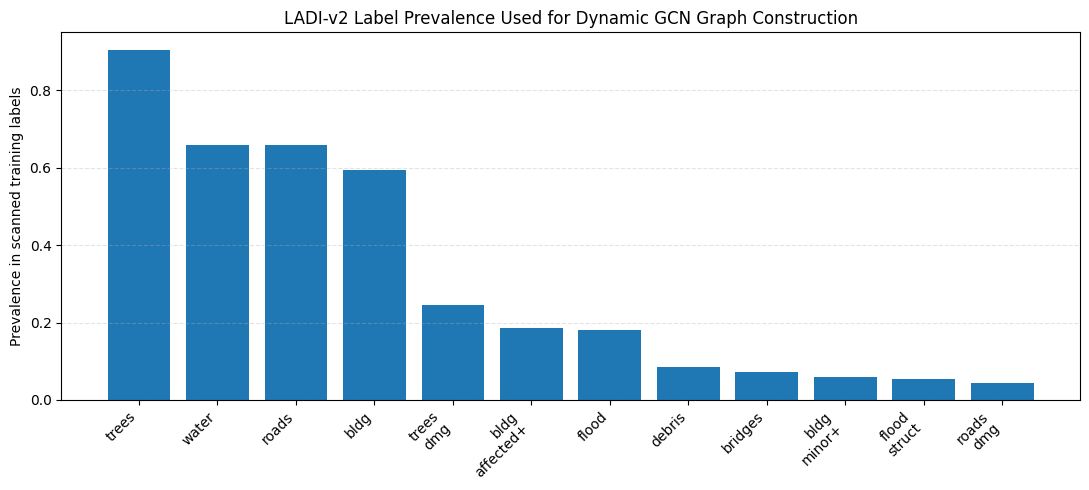

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/01_label_prevalence.png


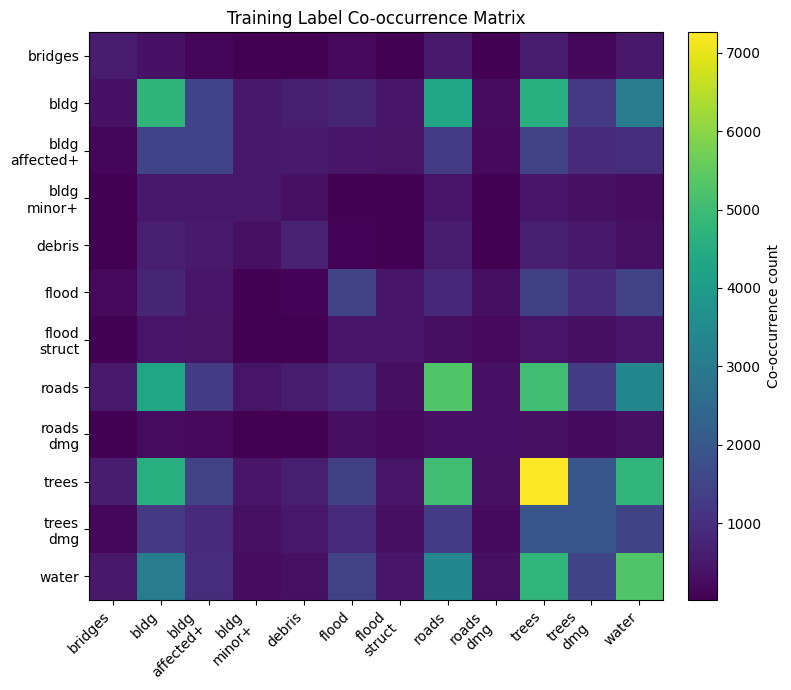

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/02_label_cooccurrence_heatmap.png


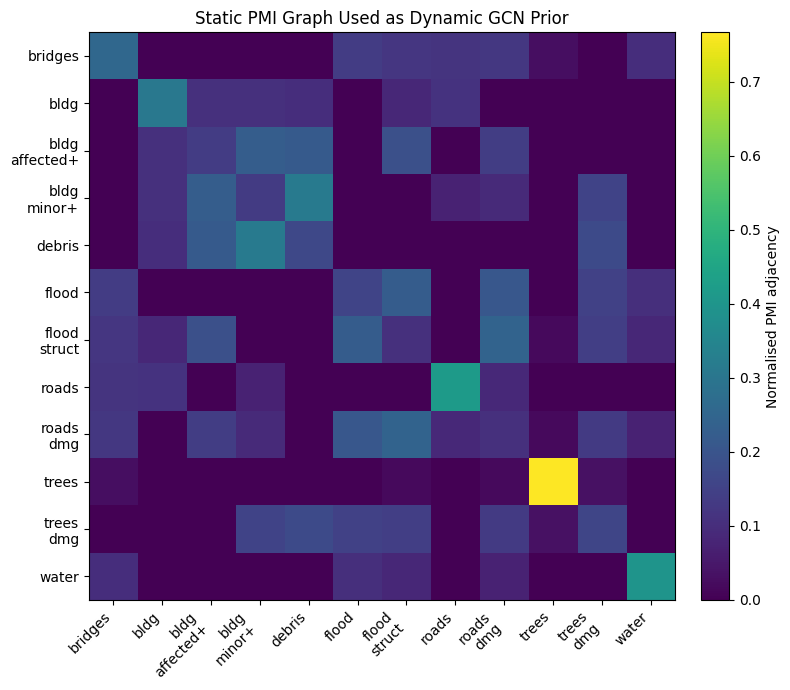

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/03_pmi_graph_heatmap.png


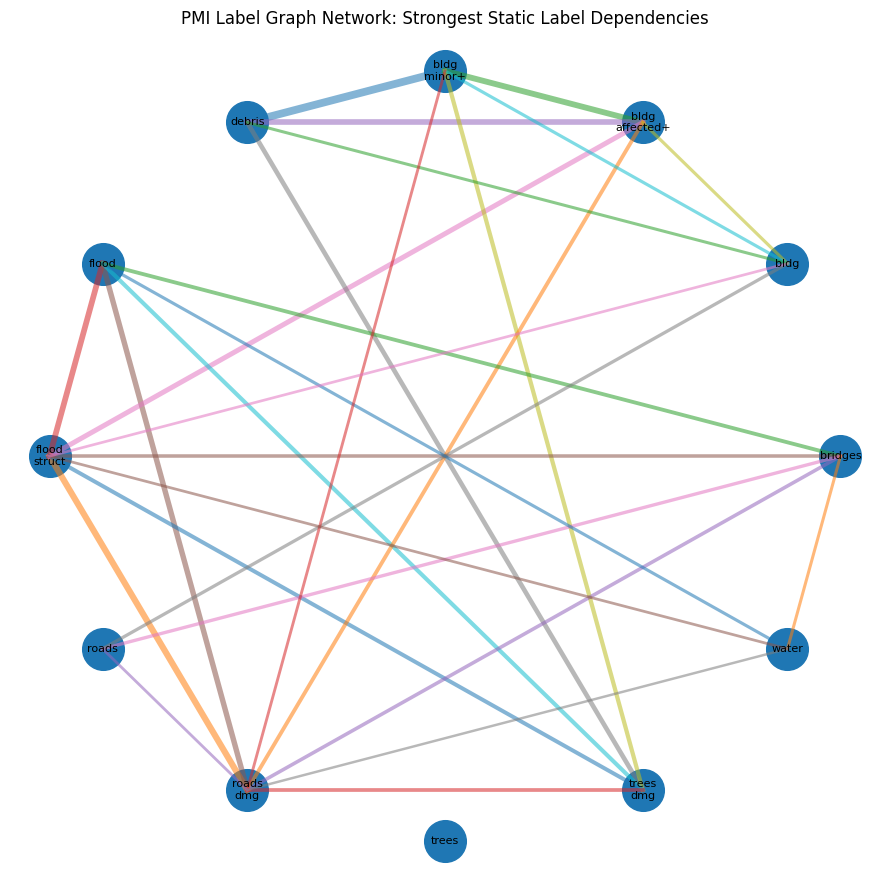

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/04_pmi_graph_network.png


In [8]:

# ============================================================
# 6A. Dataset and Static PMI Graph Visualisations
# ============================================================

def _short_label(name: str) -> str:
    """Shorter labels for compact plots."""
    return (
        name.replace("_any", "")
            .replace("_or_greater", "+")
            .replace("buildings", "bldg")
            .replace("flooding", "flood")
            .replace("structures", "struct")
            .replace("damage", "dmg")
            .replace("_", "\n")
    )

SHORT_LABELS = [_short_label(x) for x in LABEL_NAMES]

def save_show(fig, filename: str):
    """Save a matplotlib figure and show it inside the notebook."""
    path = FIG_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=PLOTS_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")

# 1) Label prevalence bar plot
prevalence = label_counts / max(n_scan, 1)
fig, ax = plt.subplots(figsize=(11, 5))
order = np.argsort(prevalence)[::-1]
ax.bar(np.arange(NUM_LABELS), prevalence[order])
ax.set_xticks(np.arange(NUM_LABELS))
ax.set_xticklabels([SHORT_LABELS[i] for i in order], rotation=45, ha="right")
ax.set_ylabel("Prevalence in scanned training labels")
ax.set_title("LADI-v2 Label Prevalence Used for Dynamic GCN Graph Construction")
ax.grid(axis="y", linestyle="--", alpha=0.35)
save_show(fig, "01_label_prevalence.png")

# 2) Raw co-occurrence heatmap
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(label_cooc, aspect="auto")
ax.set_xticks(np.arange(NUM_LABELS))
ax.set_yticks(np.arange(NUM_LABELS))
ax.set_xticklabels(SHORT_LABELS, rotation=45, ha="right")
ax.set_yticklabels(SHORT_LABELS)
ax.set_title("Training Label Co-occurrence Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Co-occurrence count")
save_show(fig, "02_label_cooccurrence_heatmap.png")

# 3) Normalised positive PMI graph heatmap
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(A_PMI, aspect="auto")
ax.set_xticks(np.arange(NUM_LABELS))
ax.set_yticks(np.arange(NUM_LABELS))
ax.set_xticklabels(SHORT_LABELS, rotation=45, ha="right")
ax.set_yticklabels(SHORT_LABELS)
ax.set_title("Static PMI Graph Used as Dynamic GCN Prior")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Normalised PMI adjacency")
save_show(fig, "03_pmi_graph_heatmap.png")

# 4) PMI graph network illustration using a circular layout
fig, ax = plt.subplots(figsize=(9, 9))
theta = np.linspace(0, 2 * np.pi, NUM_LABELS, endpoint=False)
xy = np.stack([np.cos(theta), np.sin(theta)], axis=1)

# Select strongest off-diagonal edges for readability.
edges = []
for i in range(NUM_LABELS):
    for j in range(i + 1, NUM_LABELS):
        if A_PMI[i, j] > 0:
            edges.append((i, j, float(A_PMI[i, j])))
edges = sorted(edges, key=lambda x: x[2], reverse=True)[:min(28, len(edges))]
max_w = max([e[2] for e in edges], default=1.0)

for i, j, w in edges:
    ax.plot(
        [xy[i, 0], xy[j, 0]],
        [xy[i, 1], xy[j, 1]],
        linewidth=0.6 + 5.0 * (w / max_w),
        alpha=0.55,
    )

ax.scatter(xy[:, 0], xy[:, 1], s=900)
for i, name in enumerate(SHORT_LABELS):
    ax.text(xy[i, 0], xy[i, 1], name, ha="center", va="center", fontsize=8)

ax.set_title("PMI Label Graph Network: Strongest Static Label Dependencies")
ax.axis("off")
save_show(fig, "04_pmi_graph_network.png")


In [9]:
# ============================================================
# 7. Model Definitions: FINAL Hybrid Dynamic GCN++
# ============================================================

# These two global values are updated at the beginning of each epoch.
# The schedule starts safely with a stronger static graph prior and gradually allows more dynamic graph contribution.
CURRENT_MIN_STATIC_ALPHA = MIN_STATIC_ALPHA_START
CURRENT_DYNAMIC_REG_WEIGHT = DYNAMIC_REG_WEIGHT_START


def update_dynamic_schedule(epoch: int):
    """Static-to-dynamic schedule for stable Dynamic GCN training."""
    global CURRENT_MIN_STATIC_ALPHA, CURRENT_DYNAMIC_REG_WEIGHT
    if epoch <= 2:
        CURRENT_MIN_STATIC_ALPHA = MIN_STATIC_ALPHA_START
    elif epoch <= 5:
        CURRENT_MIN_STATIC_ALPHA = MIN_STATIC_ALPHA_MID
    else:
        CURRENT_MIN_STATIC_ALPHA = MIN_STATIC_ALPHA_FINAL

    # Gradually reduce dynamic regularisation so the dynamic graph can become more useful later.
    if NUM_EPOCHS <= 1:
        progress = 1.0
    else:
        progress = min(max((epoch - 1) / (NUM_EPOCHS - 1), 0.0), 1.0)
    CURRENT_DYNAMIC_REG_WEIGHT = DYNAMIC_REG_WEIGHT_START + progress * (DYNAMIC_REG_WEIGHT_FINAL - DYNAMIC_REG_WEIGHT_START)


def build_cnn_feature_extractor(name: str):
    """Return feature extractor and feature dimension."""
    if name == "resnet18":
        try:
            weights = ResNet18_Weights.DEFAULT
            model = resnet18(weights=weights)
            print("Loaded pretrained ResNet18 weights.")
        except Exception as e:
            print("Could not load pretrained ResNet18 weights. Using random init.", repr(e))
            model = resnet18(weights=None)
        feat_dim = model.fc.in_features
        model.fc = nn.Identity()
        return model, feat_dim

    if name == "efficientnet_b0":
        try:
            weights = EfficientNet_B0_Weights.DEFAULT
            model = efficientnet_b0(weights=weights)
            print("Loaded pretrained EfficientNet-B0 weights.")
        except Exception as e:
            print("Could not load pretrained EfficientNet-B0 weights. Using random init.", repr(e))
            model = efficientnet_b0(weights=None)
        feat_dim = model.classifier[1].in_features
        model.classifier = nn.Identity()
        return model, feat_dim

    raise ValueError(f"Unknown CNN feature extractor: {name}")


def row_topk_normalise(A: torch.Tensor, k: int, eps: float = 1e-8) -> torch.Tensor:
    """Keep top-k entries per row and row-normalise. Supports [L,L] or [B,L,L]."""
    squeeze_back = False
    if A.dim() == 2:
        A = A.unsqueeze(0)
        squeeze_back = True

    if k is not None and k < A.shape[-1]:
        vals, idx = torch.topk(A, k=k, dim=-1)
        mask = torch.zeros_like(A)
        mask.scatter_(-1, idx, 1.0)
        A = A * mask

    eye = torch.eye(A.shape[-1], device=A.device, dtype=A.dtype).unsqueeze(0)
    A = torch.maximum(A, eye)
    A = A / A.sum(dim=-1, keepdim=True).clamp_min(eps)
    return A.squeeze(0) if squeeze_back else A


class BatchGCNLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, X, A):
        return self.linear(torch.bmm(A, X))


class HybridDynamicGCNClassifier(nn.Module):
    """Dynamic GCN++ with hybrid logit fusion.

    Branches:
    1. Baseline visual classifier logits from EfficientNet features.
    2. Static GCN logits using only the PMI graph.
    3. Dynamic/mixed GCN logits using static PMI + image-conditioned dynamic graph.

    The final logits are a weighted fusion of all three. This improves stability because the model
    keeps the strong visual baseline, the reliable static graph, and the adaptive dynamic graph.
    """
    def __init__(self, num_labels: int, A_static: torch.Tensor, backbone_name: str = "efficientnet_b0",
                 label_dim: int = LABEL_EMBED_DIM, hidden_dim: int = GCN_HIDDEN_DIM,
                 gate_init: float = DYNAMIC_GATE_INIT, dropout: float = DROPOUT,
                 graph_dropout: float = GRAPH_DROPOUT):
        super().__init__()
        self.backbone, feat_dim = build_cnn_feature_extractor(backbone_name)
        self.num_labels = num_labels
        self.feat_dim = feat_dim
        self.label_dim = label_dim

        # Static PMI prior is top-k sparsified and row-normalised for stable graph propagation.
        A_static = A_static.clone().float()
        A_static = row_topk_normalise(A_static, GRAPH_TOPK)
        self.register_buffer("A_static", A_static)

        # Visual baseline branch.
        self.baseline_head = nn.Linear(feat_dim, num_labels)

        # GCN label branches.
        self.label_embeddings = nn.Parameter(torch.randn(num_labels, label_dim) * 0.02)
        self.context_proj = nn.Linear(feat_dim, label_dim)
        self.node_gate = nn.Linear(feat_dim, label_dim)

        self.gcn1 = BatchGCNLayer(label_dim, hidden_dim)
        self.gcn2 = BatchGCNLayer(hidden_dim, feat_dim)
        self.static_bias = nn.Parameter(torch.zeros(num_labels))
        self.dynamic_bias = nn.Parameter(torch.zeros(num_labels))

        self.mix_gate = nn.Parameter(torch.tensor(float(gate_init)))
        self.dropout = nn.Dropout(dropout)
        self.graph_dropout = nn.Dropout(graph_dropout)

        self.last_dynamic_reg = torch.tensor(0.0)
        self.last_alpha = torch.tensor(1.0)

    def _dynamic_adjacency(self, nodes: torch.Tensor) -> torch.Tensor:
        sim = torch.bmm(nodes, nodes.transpose(1, 2)) / math.sqrt(self.label_dim)
        A_dyn = torch.softmax(sim, dim=-1)
        A_dyn = row_topk_normalise(A_dyn, DYNAMIC_TOPK)
        if self.training and GRAPH_DROPOUT > 0:
            A_dyn = self.graph_dropout(A_dyn)
            A_dyn = A_dyn / A_dyn.sum(dim=-1, keepdim=True).clamp_min(1e-8)
        return A_dyn

    def _gcn_logits(self, nodes: torch.Tensor, A: torch.Tensor, feat: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
        Z = F.relu(self.gcn1(nodes, A))
        Z = self.dropout(Z)
        W = self.gcn2(Z, A)  # [B, L, F]
        return torch.einsum("bf,blf->bl", feat, W) + bias

    def forward(self, x, return_graphs: bool = False, return_branches: bool = False):
        feat = self.backbone(x)  # [B, F]
        feat_d = self.dropout(feat)
        B = feat.shape[0]
        L = self.num_labels

        # Branch 1: visual baseline logits.
        baseline_logits = self.baseline_head(feat_d)

        # Label nodes conditioned by image context.
        base_nodes = self.label_embeddings.unsqueeze(0).expand(B, L, self.label_dim)
        context = torch.tanh(self.context_proj(feat)).unsqueeze(1)
        gate = torch.sigmoid(self.node_gate(feat)).unsqueeze(1)
        nodes = base_nodes + gate * context

        A_dyn = self._dynamic_adjacency(nodes)
        A_static = self.A_static.unsqueeze(0).expand(B, L, L)

        # Static-to-dynamic scheduled graph gate.
        raw_alpha = torch.sigmoid(self.mix_gate)
        alpha = CURRENT_MIN_STATIC_ALPHA + (1.0 - CURRENT_MIN_STATIC_ALPHA) * raw_alpha
        A_mix = alpha * A_static + (1.0 - alpha) * A_dyn
        A_mix = A_mix / A_mix.sum(dim=-1, keepdim=True).clamp_min(1e-8)

        # Branch 2: static GCN logits.
        static_logits = self._gcn_logits(nodes, A_static, feat_d, self.static_bias)

        # Branch 3: dynamic/mixed GCN logits.
        dynamic_logits = self._gcn_logits(nodes, A_mix, feat_d, self.dynamic_bias)

        # Hybrid fusion.
        final_logits = (
            HYBRID_BASELINE_WEIGHT * baseline_logits
            + HYBRID_STATIC_WEIGHT * static_logits
            + HYBRID_DYNAMIC_WEIGHT * dynamic_logits
        )

        self.last_dynamic_reg = F.mse_loss(A_dyn, A_static)
        self.last_alpha = alpha.detach()

        if return_graphs:
            return final_logits, A_static, A_dyn, A_mix, alpha.detach()
        if return_branches:
            return final_logits, baseline_logits, static_logits, dynamic_logits
        return final_logits


def set_backbone_trainability(model: nn.Module, epoch: int):
    """Freeze backbone early; then unfreeze last EfficientNet blocks only for P100 stability."""
    if not hasattr(model, "backbone"):
        return
    freeze = epoch <= FREEZE_BACKBONE_EPOCHS
    for p in model.backbone.parameters():
        p.requires_grad = False

    if freeze:
        print(f"Epoch {epoch}: backbone frozen; training hybrid graph/head only.")
        return

    if UNFREEZE_LAST_BLOCKS_ONLY and hasattr(model.backbone, "features"):
        # EfficientNet-B0: unfreeze final feature blocks for adaptation without full-backbone overfitting.
        for block in list(model.backbone.features)[-3:]:
            for p in block.parameters():
                p.requires_grad = True
        print(f"Epoch {epoch}: unfroze final EfficientNet feature blocks only.")
    else:
        for p in model.backbone.parameters():
            p.requires_grad = True
        print(f"Epoch {epoch}: full backbone unfrozen.")


def build_model(run_model: str) -> nn.Module:
    if run_model.startswith("dynamic_gcn_efficientnet_b0"):
        return HybridDynamicGCNClassifier(NUM_LABELS, A_PMI_TENSOR, backbone_name="efficientnet_b0")
    raise ValueError(f"This notebook is optimised only for Dynamic GCN++ EfficientNet-B0, got: {run_model}")


print("Model definitions ready. Each seed will instantiate its own fresh HybridDynamicGCNClassifier.")
print("Fusion weights:", {
    "baseline": HYBRID_BASELINE_WEIGHT,
    "static": HYBRID_STATIC_WEIGHT,
    "dynamic": HYBRID_DYNAMIC_WEIGHT,
})


Model definitions ready. Each seed will instantiate its own fresh HybridDynamicGCNClassifier.
Fusion weights: {'baseline': 0.3, 'static': 0.35, 'dynamic': 0.35}


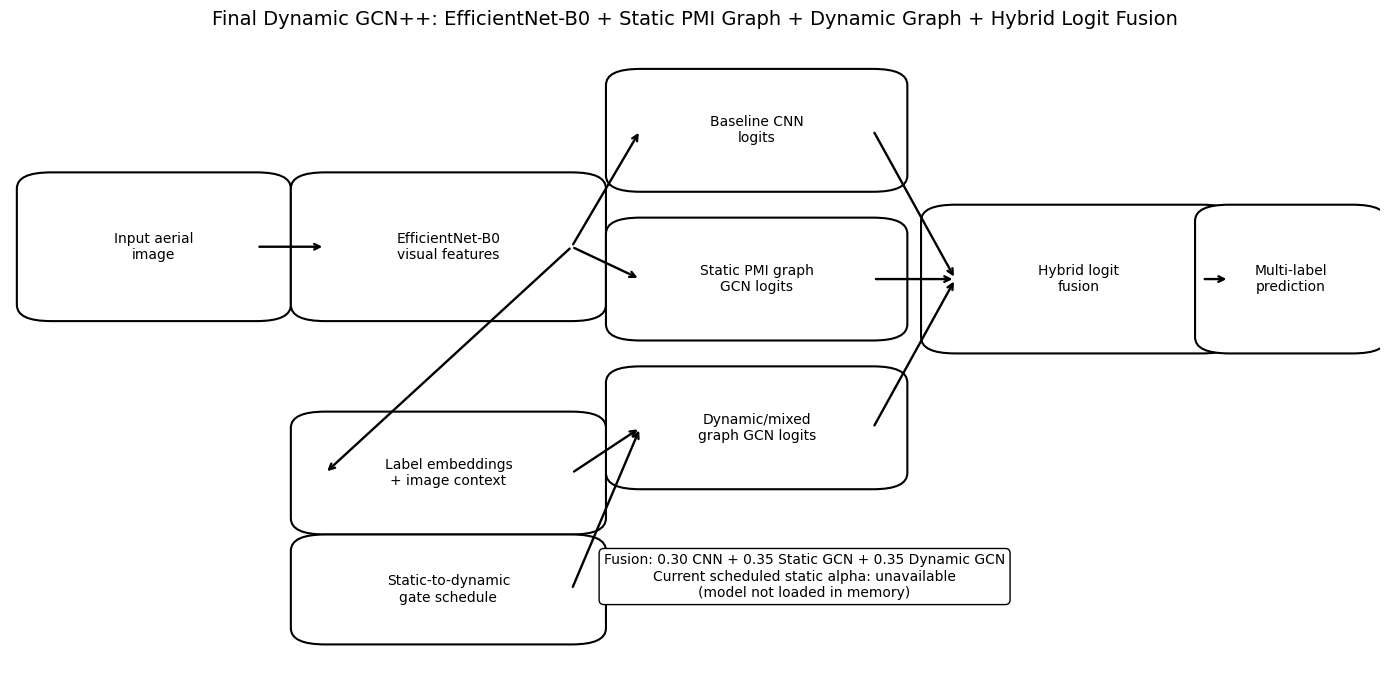

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/05_dynamic_gcn_hybrid_architecture.png


In [10]:
# ============================================================
# 7A. Dynamic GCN++ Hybrid Architecture Illustration
# Fixed version: safe even if model is not currently defined
# ============================================================

def draw_dynamic_gcn_architecture():
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.axis("off")

    boxes = [
        (0.03, 0.58, 0.15, 0.18, "Input aerial\nimage"),
        (0.23, 0.58, 0.18, 0.18, "EfficientNet-B0\nvisual features"),
        (0.46, 0.78, 0.17, 0.14, "Baseline CNN\nlogits"),
        (0.46, 0.55, 0.17, 0.14, "Static PMI graph\nGCN logits"),
        (0.46, 0.32, 0.17, 0.14, "Dynamic/mixed\ngraph GCN logits"),
        (0.69, 0.53, 0.18, 0.18, "Hybrid logit\nfusion"),
        (0.89, 0.53, 0.09, 0.18, "Multi-label\nprediction"),
        (0.23, 0.25, 0.18, 0.14, "Label embeddings\n+ image context"),
        (0.23, 0.08, 0.18, 0.12, "Static-to-dynamic\ngate schedule"),
    ]

    for x, y, w, h, label in boxes:
        box = patches.FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.025,rounding_size=0.025",
            linewidth=1.5,
            edgecolor="black",
            facecolor="white",
        )
        ax.add_patch(box)
        ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=10)

    arrows = [
        ((0.18, 0.67), (0.23, 0.67)),
        ((0.41, 0.67), (0.46, 0.85)),
        ((0.41, 0.67), (0.46, 0.62)),
        ((0.41, 0.32), (0.46, 0.39)),
        ((0.41, 0.14), (0.46, 0.39)),
        ((0.63, 0.85), (0.69, 0.62)),
        ((0.63, 0.62), (0.69, 0.62)),
        ((0.63, 0.39), (0.69, 0.62)),
        ((0.87, 0.62), (0.89, 0.62)),
        ((0.41, 0.67), (0.23, 0.32)),
    ]

    for start, end in arrows:
        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="->", linewidth=1.7),
        )

    # ------------------------------------------------------------
    # Safe fallback values
    # ------------------------------------------------------------
    baseline_w = globals().get("HYBRID_BASELINE_WEIGHT", 0.30)
    static_w = globals().get("HYBRID_STATIC_WEIGHT", 0.35)
    dynamic_w = globals().get("HYBRID_DYNAMIC_WEIGHT", 0.35)

    min_static_alpha = globals().get(
        "CURRENT_MIN_STATIC_ALPHA",
        globals().get("MIN_STATIC_ALPHA", 0.55)
    )

    # ------------------------------------------------------------
    # Safe graph-gate extraction
    # This avoids NameError if model is not currently defined.
    # ------------------------------------------------------------
    if "model" in globals() and hasattr(globals()["model"], "mix_gate"):
        try:
            current_model = globals()["model"]
            raw_alpha = torch.sigmoid(current_model.mix_gate).detach().cpu().item()
            alpha_now = min_static_alpha + (1.0 - min_static_alpha) * raw_alpha
            alpha_text = f"Current scheduled static alpha ≈ {alpha_now:.3f}"
        except Exception as e:
            alpha_text = "Current scheduled static alpha: unavailable"
            print("Warning: could not read model.mix_gate:", e)
    else:
        alpha_text = "Current scheduled static alpha: unavailable\n(model not loaded in memory)"

    ax.text(
        0.58,
        0.16,
        f"Fusion: {baseline_w:.2f} CNN + {static_w:.2f} Static GCN + {dynamic_w:.2f} Dynamic GCN\n"
        f"{alpha_text}",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black"),
    )

    ax.set_title(
        "Final Dynamic GCN++: EfficientNet-B0 + Static PMI Graph + Dynamic Graph + Hybrid Logit Fusion",
        fontsize=14,
    )

    return fig


fig = draw_dynamic_gcn_architecture()
save_show(fig, "05_dynamic_gcn_hybrid_architecture.png")

In [11]:
# ============================================================
# 8. Metrics, Calibration, and Threshold Tuning
# ============================================================

def safe_average_precision(y_true, y_prob):
    scores = []
    for j in range(y_true.shape[1]):
        if len(np.unique(y_true[:, j])) < 2:
            scores.append(np.nan)
        else:
            scores.append(average_precision_score(y_true[:, j], y_prob[:, j]))
    return np.array(scores, dtype=np.float64)


def tune_thresholds(y_true: np.ndarray, y_prob: np.ndarray, grid=None, beta: float = THRESHOLD_BETA) -> np.ndarray:
    """Tune thresholds on validation set using F-beta. Beta>1 improves recall for rare labels."""
    if grid is None:
        grid = np.arange(THRESHOLD_MIN, THRESHOLD_MAX + 1e-9, THRESHOLD_STEP)
    thresholds = np.full(y_true.shape[1], 0.5, dtype=np.float32)
    beta2 = beta ** 2
    for j in range(y_true.shape[1]):
        best_score = -1.0
        best_t = 0.5
        if len(np.unique(y_true[:, j])) < 2:
            thresholds[j] = 0.5
            continue
        for t in grid:
            pred = (y_prob[:, j] >= t).astype(int)
            precision = precision_score(y_true[:, j], pred, zero_division=0)
            recall = recall_score(y_true[:, j], pred, zero_division=0)
            score = (1 + beta2) * precision * recall / max(beta2 * precision + recall, 1e-12)
            if score > best_score:
                best_score = score
                best_t = float(t)
        thresholds[j] = best_t
    return thresholds


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, thresholds: Optional[np.ndarray] = None) -> Dict[str, Any]:
    if thresholds is None:
        thresholds = np.full(y_true.shape[1], 0.5, dtype=np.float32)
    y_pred = (y_prob >= thresholds.reshape(1, -1)).astype(int)
    per_label_ap = safe_average_precision(y_true, y_prob)
    per_label_f1 = np.array([
        f1_score(y_true[:, j], y_pred[:, j], zero_division=0)
        for j in range(y_true.shape[1])
    ])
    per_label_precision = np.array([
        precision_score(y_true[:, j], y_pred[:, j], zero_division=0)
        for j in range(y_true.shape[1])
    ])
    per_label_recall = np.array([
        recall_score(y_true[:, j], y_pred[:, j], zero_division=0)
        for j in range(y_true.shape[1])
    ])
    metrics = {
        "macro_ap": float(np.nanmean(per_label_ap)),
        "micro_ap": float(average_precision_score(y_true.ravel(), y_prob.ravel())) if len(np.unique(y_true.ravel())) > 1 else float("nan"),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "micro_f1": float(f1_score(y_true, y_pred, average="micro", zero_division=0)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "per_label_ap": {LABEL_NAMES[i]: None if np.isnan(per_label_ap[i]) else float(per_label_ap[i]) for i in range(NUM_LABELS)},
        "per_label_f1": {LABEL_NAMES[i]: float(per_label_f1[i]) for i in range(NUM_LABELS)},
        "per_label_precision": {LABEL_NAMES[i]: float(per_label_precision[i]) for i in range(NUM_LABELS)},
        "per_label_recall": {LABEL_NAMES[i]: float(per_label_recall[i]) for i in range(NUM_LABELS)},
        "thresholds": {LABEL_NAMES[i]: float(thresholds[i]) for i in range(NUM_LABELS)},
    }
    return metrics


def fit_temperature_scaling_from_probs(y_true: np.ndarray, y_prob: np.ndarray, max_iter: int = 200) -> np.ndarray:
    """Per-label temperature scaling fitted on validation probabilities."""
    if not USE_TEMPERATURE_SCALING:
        return np.ones(y_true.shape[1], dtype=np.float32)
    p = np.clip(y_prob, 1e-5, 1 - 1e-5)
    logits_np = np.log(p / (1.0 - p))
    logits = torch.tensor(logits_np, dtype=torch.float32, device=DEVICE)
    targets = torch.tensor(y_true, dtype=torch.float32, device=DEVICE)
    log_t = torch.zeros(logits.shape[1], dtype=torch.float32, device=DEVICE, requires_grad=True)
    opt = torch.optim.LBFGS([log_t], lr=0.1, max_iter=max_iter, line_search_fn="strong_wolfe")
    bce = nn.BCEWithLogitsLoss()

    def closure():
        opt.zero_grad()
        temp = torch.exp(log_t).clamp(0.5, 5.0)
        loss = bce(logits / temp.view(1, -1), targets)
        loss.backward()
        return loss

    try:
        opt.step(closure)
        temps = torch.exp(log_t).clamp(0.5, 5.0).detach().cpu().numpy().astype(np.float32)
    except Exception as e:
        print("Temperature scaling failed; using temperature=1.0.", repr(e))
        temps = np.ones(logits.shape[1], dtype=np.float32)
    return temps


def apply_temperature_scaling_to_probs(y_prob: np.ndarray, temperatures: np.ndarray) -> np.ndarray:
    p = np.clip(y_prob, 1e-5, 1 - 1e-5)
    logits = np.log(p / (1.0 - p))
    calibrated = 1.0 / (1.0 + np.exp(-(logits / temperatures.reshape(1, -1))))
    return calibrated.astype(np.float32)


def save_predictions_csv(ids: List[str], y_true: np.ndarray, y_prob: np.ndarray, thresholds: np.ndarray, path: Path):
    data = {"sample_id": ids}
    y_pred = (y_prob >= thresholds.reshape(1, -1)).astype(int)
    for i, label in enumerate(LABEL_NAMES):
        data[f"true_{label}"] = y_true[:, i].astype(int)
        data[f"prob_{label}"] = y_prob[:, i]
        data[f"pred_{label}"] = y_pred[:, i].astype(int)
    pd.DataFrame(data).to_csv(path, index=False)

print("Metric, calibration, and threshold utilities ready.")


Metric, calibration, and threshold utilities ready.


In [12]:
# ============================================================
# 9. Multi-Seed Training and Evaluation Functions
# ============================================================

class AsymmetricLossWithLogits(nn.Module):
    """Moderate asymmetric loss for imbalanced multi-label classification."""
    def __init__(self, gamma_pos=0.0, gamma_neg=2.0, clip=0.03, eps=1e-8, label_smoothing=0.0):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.eps = eps
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        if self.label_smoothing > 0:
            targets = targets * (1.0 - self.label_smoothing) + 0.5 * self.label_smoothing

        xs_pos = torch.sigmoid(logits)
        xs_neg = 1.0 - xs_pos

        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)

        loss_pos = targets * torch.log(xs_pos.clamp(min=self.eps))
        loss_neg = (1.0 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss = loss_pos + loss_neg

        if self.gamma_pos > 0 or self.gamma_neg > 0:
            pt = xs_pos * targets + xs_neg * (1.0 - targets)
            gamma = self.gamma_pos * targets + self.gamma_neg * (1.0 - targets)
            loss = loss * torch.pow((1.0 - pt).clamp(min=0.0), gamma)

        return -loss.mean()


def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_criterion():
    if USE_ASYMMETRIC_LOSS:
        print("Using moderate AsymmetricLossWithLogits.")
        return AsymmetricLossWithLogits(
            gamma_pos=ASYM_GAMMA_POS,
            gamma_neg=ASYM_GAMMA_NEG,
            clip=ASYM_CLIP,
            label_smoothing=LABEL_SMOOTHING,
        )
    print("Using BCEWithLogitsLoss with pos_weight.")
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def make_optimizer_scheduler_scaler(model: nn.Module):
    backbone_params, dynamic_params, graph_head_params = [], [], []
    for name, p in model.named_parameters():
        if name.startswith("backbone."):
            backbone_params.append(p)
        elif name.startswith("context_proj.") or name.startswith("node_gate.") or name == "mix_gate":
            dynamic_params.append(p)
        else:
            graph_head_params.append(p)

    param_groups = []
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": BACKBONE_LR, "group_name": "backbone"})
    if dynamic_params:
        param_groups.append({"params": dynamic_params, "lr": DYNAMIC_GRAPH_LR, "group_name": "dynamic_graph"})
    if graph_head_params:
        param_groups.append({"params": graph_head_params, "lr": GRAPH_HEAD_LR, "group_name": "graph_head"})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(NUM_EPOCHS, 1),
        eta_min=1e-6,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))
    return optimizer, scheduler, scaler


def get_group_lr(optimizer, name: str) -> Optional[float]:
    for group in optimizer.param_groups:
        if group.get("group_name") == name:
            return float(group["lr"])
    return None


def train_one_epoch_for_seed(model, criterion, optimizer, scheduler, scaler, epoch: int, seed: int) -> float:
    update_dynamic_schedule(epoch)
    set_backbone_trainability(model, epoch)
    model.train()

    loader = make_loader("train", train=True, limit=TRAIN_LIMIT, seed=seed + epoch)
    total_loss = 0.0
    total_batches = 0

    pbar = tqdm(loader, desc=f"Seed {seed} | Epoch {epoch} train")
    optimizer.zero_grad(set_to_none=True)

    for step, (x, y, _) in enumerate(pbar):
        if MAX_TRAIN_STEPS_PER_EPOCH is not None and step >= MAX_TRAIN_STEPS_PER_EPOCH:
            break

        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(USE_AMP and DEVICE.type == "cuda")):
            logits = model(x)
            base_loss = criterion(logits, y)
            graph_reg = getattr(model, "last_dynamic_reg", torch.tensor(0.0, device=DEVICE))
            loss = base_loss + CURRENT_DYNAMIC_REG_WEIGHT * graph_reg
            loss_for_backward = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss_for_backward).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += float(loss.detach().cpu())
        total_batches += 1
        alpha_value = float(getattr(model, "last_alpha", torch.tensor(float("nan"))).detach().cpu())
        pbar.set_postfix({
            "loss": total_loss / max(total_batches, 1),
            "base": float(base_loss.detach().cpu()),
            "greg": float(graph_reg.detach().cpu()),
            "alpha": alpha_value,
        })

    # Final optimiser step for a non-divisible number of batches.
    if total_batches > 0 and total_batches % GRAD_ACCUM_STEPS != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    scheduler.step()
    return total_loss / max(total_batches, 1)


@torch.no_grad()
def predict_split_for_model(model: nn.Module, split: str, limit: Optional[int], seed: int) -> Tuple[List[str], np.ndarray, np.ndarray]:
    model.eval()
    loader = make_loader(split, train=False, limit=limit, seed=seed)
    all_ids, all_probs, all_targets = [], [], []
    for x, y, ids in tqdm(loader, desc=f"Predict {split} | seed {seed}"):
        x = x.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(USE_AMP and DEVICE.type == "cuda")):
            logits = model(x)
            probs = torch.sigmoid(logits)
        all_ids.extend(list(ids))
        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(y.numpy())
    if not all_probs:
        raise RuntimeError(f"No predictions collected for split={split}. Check dataset loading.")
    return all_ids, np.concatenate(all_targets, axis=0), np.concatenate(all_probs, axis=0)


def seed_output_dir(seed: int) -> Path:
    out = BASE_OUTPUT_DIR / f"seed_{seed}"
    out.mkdir(parents=True, exist_ok=True)
    (out / "figures").mkdir(parents=True, exist_ok=True)
    return out


def train_and_evaluate_one_seed(seed: int) -> Dict[str, Any]:
    """Train one seed, save best checkpoint, evaluate validation/test, and return summary."""
    set_all_seeds(seed)
    out_dir = seed_output_dir(seed)
    best_path = out_dir / "best_model.pt"

    model = build_model(RUN_MODEL).to(DEVICE)
    criterion = make_criterion()
    optimizer, scheduler, scaler = make_optimizer_scheduler_scaler(model)

    print("\n" + "=" * 80)
    print(f"Starting seed {seed}")
    print("Output dir:", out_dir)
    print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
    print("Optimizer groups:", [(g.get("group_name"), g["lr"], len(g["params"])) for g in optimizer.param_groups])
    print("=" * 80)

    history = []
    best_score = -1.0
    best_thresholds = None
    best_temperatures = None
    bad_epochs = 0
    patience = 4

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch_for_seed(model, criterion, optimizer, scheduler, scaler, epoch, seed)

        # Runtime-saving validation schedule:
        # validate every VALIDATE_EVERY epochs and at the final epoch.
        # This keeps 8 epochs per seed but avoids unnecessary validation passes.
        do_validate = (epoch % VALIDATE_EVERY == 0) or (epoch == NUM_EPOCHS)

        alpha_value = None
        if hasattr(model, "mix_gate"):
            with torch.no_grad():
                raw_alpha = torch.sigmoid(model.mix_gate)
                alpha_value = float((CURRENT_MIN_STATIC_ALPHA + (1.0 - CURRENT_MIN_STATIC_ALPHA) * raw_alpha).detach().cpu())

        if do_validate:
            val_ids, y_val, p_val_raw = predict_split_for_model(model, "validation", VAL_LIMIT, seed)
            temperatures = fit_temperature_scaling_from_probs(y_val, p_val_raw) if USE_TEMPERATURE_SCALING else np.ones(NUM_LABELS, dtype=np.float32)
            p_val = apply_temperature_scaling_to_probs(p_val_raw, temperatures)
            thresholds = tune_thresholds(y_val, p_val)
            val_metrics = compute_metrics(y_val, p_val, thresholds)

            selection_score = val_metrics["macro_ap"] + SELECTION_F1_WEIGHT * val_metrics["macro_f1"]

            row = {
                "seed": seed,
                "epoch": epoch,
                "train_loss": train_loss,
                "validated": True,
                "val_macro_ap": val_metrics["macro_ap"],
                "val_micro_ap": val_metrics["micro_ap"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_micro_f1": val_metrics["micro_f1"],
                "selection_score": selection_score,
                "static_alpha": alpha_value,
                "current_min_static_alpha": CURRENT_MIN_STATIC_ALPHA,
                "current_dynamic_reg_weight": CURRENT_DYNAMIC_REG_WEIGHT,
                "backbone_lr": get_group_lr(optimizer, "backbone"),
                "dynamic_graph_lr": get_group_lr(optimizer, "dynamic_graph"),
                "graph_head_lr": get_group_lr(optimizer, "graph_head"),
            }
            history.append(row)
            pd.DataFrame(history).to_csv(out_dir / "history.csv", index=False)
            print(json.dumps(row, indent=2))

            if selection_score > best_score:
                best_score = selection_score
                best_thresholds = thresholds.copy()
                best_temperatures = temperatures.copy()
                bad_epochs = 0
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "seed": seed,
                    "run_model": RUN_MODEL,
                    "label_names": LABEL_NAMES,
                    "thresholds": best_thresholds.tolist(),
                    "temperatures": best_temperatures.tolist(),
                    "val_metrics": val_metrics,
                    "selection_score": best_score,
                    "validated_epoch": epoch,
                }, best_path)
                print(f"New best seed {seed} model saved: {best_path}")
            else:
                bad_epochs += 1
                print(f"No improvement for seed {seed}. bad_epochs={bad_epochs}/{patience}")

            if bad_epochs >= patience:
                print(f"Early stopping seed {seed} at epoch {epoch}.")
                break

        else:
            row = {
                "seed": seed,
                "epoch": epoch,
                "train_loss": train_loss,
                "validated": False,
                "val_macro_ap": np.nan,
                "val_micro_ap": np.nan,
                "val_macro_f1": np.nan,
                "val_micro_f1": np.nan,
                "selection_score": np.nan,
                "static_alpha": alpha_value,
                "current_min_static_alpha": CURRENT_MIN_STATIC_ALPHA,
                "current_dynamic_reg_weight": CURRENT_DYNAMIC_REG_WEIGHT,
                "backbone_lr": get_group_lr(optimizer, "backbone"),
                "dynamic_graph_lr": get_group_lr(optimizer, "dynamic_graph"),
                "graph_head_lr": get_group_lr(optimizer, "graph_head"),
            }
            history.append(row)
            pd.DataFrame(history).to_csv(out_dir / "history.csv", index=False)
            print(json.dumps(row, indent=2))
            print(f"Skipped validation for seed {seed}, epoch {epoch}; next validation at epoch {epoch + (VALIDATE_EVERY - epoch % VALIDATE_EVERY)} or final epoch.")

    # Load best checkpoint and evaluate validation/test with the best calibration/thresholds.
    ckpt = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    best_thresholds = np.array(ckpt["thresholds"], dtype=np.float32)
    best_temperatures = np.array(ckpt.get("temperatures", [1.0] * NUM_LABELS), dtype=np.float32)

    # Save validation predictions too; needed for ensemble threshold tuning.
    val_ids, y_val, p_val_raw = predict_split_for_model(model, "validation", VAL_LIMIT, seed)
    p_val = apply_temperature_scaling_to_probs(p_val_raw, best_temperatures)
    save_predictions_csv(val_ids, y_val, p_val, best_thresholds, out_dir / "val_predictions.csv")

    test_ids, y_test, p_test_raw = predict_split_for_model(model, "test", TEST_LIMIT, seed)
    p_test = apply_temperature_scaling_to_probs(p_test_raw, best_temperatures)
    test_metrics = compute_metrics(y_test, p_test, best_thresholds)
    save_predictions_csv(test_ids, y_test, p_test, best_thresholds, out_dir / "test_predictions.csv")

    with open(out_dir / "test_metrics.json", "w") as f:
        json.dump(test_metrics, f, indent=2)

    per_label_rows = []
    for label in LABEL_NAMES:
        per_label_rows.append({
            "label": label,
            "ap": test_metrics["per_label_ap"][label],
            "f1": test_metrics["per_label_f1"][label],
            "precision": test_metrics["per_label_precision"][label],
            "recall": test_metrics["per_label_recall"][label],
            "threshold": test_metrics["thresholds"][label],
            "temperature": float(best_temperatures[LABEL_NAMES.index(label)]),
        })
    pd.DataFrame(per_label_rows).to_csv(out_dir / "test_per_label_metrics.csv", index=False)

    summary = {
        "seed": seed,
        "best_val_macro_ap": ckpt["val_metrics"]["macro_ap"],
        "best_val_macro_f1": ckpt["val_metrics"]["macro_f1"],
        "selection_score": ckpt["selection_score"],
        "test_macro_ap": test_metrics["macro_ap"],
        "test_micro_ap": test_metrics["micro_ap"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_micro_f1": test_metrics["micro_f1"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "output_dir": str(out_dir),
    }

    with open(out_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    # Free memory before next seed.
    del model, optimizer, scheduler, scaler, criterion
    gc.collect()
    torch.cuda.empty_cache()

    return summary

print("Multi-seed training/evaluation functions ready.")


Multi-seed training/evaluation functions ready.


In [13]:
# ============================================================
# 10. Run Multi-Seed Training
# Time-optimised plan:
# - 3 seeds
# - 8 epochs per seed
# - 288x288 images
# - validation every 2 epochs
# - test once per seed after best checkpoint
# ============================================================

seed_summaries = []

for seed in SEEDS:
    summary = train_and_evaluate_one_seed(seed)
    seed_summaries.append(summary)
    pd.DataFrame(seed_summaries).to_csv(BASE_OUTPUT_DIR / "seed_level_summary.csv", index=False)

seed_summary_df = pd.DataFrame(seed_summaries)
print("\nSeed-level summary:")
display(seed_summary_df)

# Mean ± standard deviation across seeds.
metric_cols = [
    "best_val_macro_ap",
    "best_val_macro_f1",
    "test_macro_ap",
    "test_micro_ap",
    "test_macro_f1",
    "test_micro_f1",
    "test_macro_precision",
    "test_macro_recall",
]

mean_std_rows = []
for col in metric_cols:
    mean_std_rows.append({
        "metric": col,
        "mean": float(seed_summary_df[col].mean()),
        "std": float(seed_summary_df[col].std(ddof=1)) if len(seed_summary_df) > 1 else 0.0,
        "min": float(seed_summary_df[col].min()),
        "max": float(seed_summary_df[col].max()),
    })

mean_std_df = pd.DataFrame(mean_std_rows)
mean_std_df.to_csv(BASE_OUTPUT_DIR / "mean_std_summary.csv", index=False)
print("\nMean ± std summary:")
display(mean_std_df)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s] 


Loaded pretrained EfficientNet-B0 weights.
Using moderate AsymmetricLossWithLogits.

Starting seed 42
Output dir: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/seed_42
Trainable parameters: 5470113
Optimizer groups: [('backbone', 3e-05, 211), ('dynamic_graph', 8e-05, 5), ('graph_head', 0.0001, 9)]
Epoch 1: backbone frozen; training hybrid graph/head only.


Seed 42 | Epoch 1 train: 0it [00:00, ?it/s]

{
  "seed": 42,
  "epoch": 1,
  "train_loss": 0.21787777346239162,
  "validated": false,
  "val_macro_ap": NaN,
  "val_micro_ap": NaN,
  "val_macro_f1": NaN,
  "val_micro_f1": NaN,
  "selection_score": NaN,
  "static_alpha": 0.9431759715080261,
  "current_min_static_alpha": 0.75,
  "current_dynamic_reg_weight": 0.01,
  "backbone_lr": 2.8896253221413658e-05,
  "dynamic_graph_lr": 7.699324153419583e-05,
  "graph_head_lr": 9.623203685930869e-05
}
Skipped validation for seed 42, epoch 1; next validation at epoch 2 or final epoch.
Epoch 2: unfroze final EfficientNet feature blocks only.


Seed 42 | Epoch 2 train: 0it [00:00, ?it/s]

...

Predict test | seed 2024: 0it [00:00, ?it/s]


Seed-level summary:


,seed,best_val_macro_ap,best_val_macro_f1,selection_score,test_macro_ap,test_micro_ap,test_macro_f1,test_micro_f1,test_macro_precision,test_macro_recall,output_dir
0,42,0.708545,0.684917,0.845529,0.543957,0.912676,0.515997,0.795800,0.505360,0.587567,/kaggle/working/ladi_multiseed_runs/dynamic_gc...
1,123,0.697637,0.670925,0.831822,0.531523,0.904024,0.486996,0.780326,0.477719,0.594710,/kaggle/working/ladi_multiseed_runs/dynamic_gc...
2,2024,0.715729,0.686624,0.853054,0.545039,0.905705,0.504839,0.805563,0.509701,0.552967,/kaggle/working/ladi_multiseed_runs/dynamic_gc...



Mean ± std summary:


,metric,mean,std,min,max
0,best_val_macro_ap,0.707304,0.009110,0.697637,0.715729
1,best_val_macro_f1,0.680822,0.008614,0.670925,0.686624
2,test_macro_ap,0.540173,0.007511,0.531523,0.545039
3,test_micro_ap,0.907468,0.004588,0.904024,0.912676
4,test_macro_f1,0.502611,0.014629,0.486996,0.515997
5,test_micro_f1,0.793896,0.012726,0.780326,0.805563
6,test_macro_precision,0.497593,0.017348,0.477719,0.509701
7,test_macro_recall,0.578415,0.022326,0.552967,0.594710


In [14]:
# ============================================================
# 11. Probability Ensemble Across Seeds
# ============================================================

ENSEMBLE_DIR = BASE_OUTPUT_DIR / "ensemble"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)


def load_prediction_file(seed: int, split: str) -> pd.DataFrame:
    path = seed_output_dir(seed) / f"{split}_predictions.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing prediction file: {path}")
    df = pd.read_csv(path)
    return df


def extract_arrays_from_prediction_df(df: pd.DataFrame):
    """Return ids, y_true, and probability matrix from saved prediction CSV."""
    id_col = "id" if "id" in df.columns else ("sample_id" if "sample_id" in df.columns else df.columns[0])
    ids = df[id_col].astype(str).tolist()

    y_cols = [f"true_{label}" for label in LABEL_NAMES]
    p_cols = [f"prob_{label}" for label in LABEL_NAMES]

    missing_y = [c for c in y_cols if c not in df.columns]
    missing_p = [c for c in p_cols if c not in df.columns]
    if missing_y or missing_p:
        raise ValueError(f"Prediction CSV columns not as expected. Missing y={missing_y}, p={missing_p}")

    y = df[y_cols].values.astype(np.float32)
    p = df[p_cols].values.astype(np.float32)
    return ids, y, p


def average_seed_predictions(split: str):
    all_probs = []
    ref_ids, ref_y = None, None

    for seed in SEEDS:
        df = load_prediction_file(seed, split)
        ids, y, p = extract_arrays_from_prediction_df(df)
        if ref_ids is None:
            ref_ids, ref_y = ids, y
        else:
            if ids != ref_ids:
                raise RuntimeError(
                    f"Prediction order mismatch for split={split}, seed={seed}. "
                    "Use identical VAL/TEST_LIMIT and non-shuffled evaluation loaders."
                )
            if not np.array_equal(y, ref_y):
                raise RuntimeError(f"True label mismatch for split={split}, seed={seed}.")
        all_probs.append(p)

    p_ens = np.mean(np.stack(all_probs, axis=0), axis=0)
    return ref_ids, ref_y, p_ens

# Average calibrated validation probabilities, tune ensemble thresholds on validation, then apply to test.
val_ids_ens, y_val_ens, p_val_ens = average_seed_predictions("val")
ensemble_thresholds = tune_thresholds(y_val_ens, p_val_ens)
ensemble_val_metrics = compute_metrics(y_val_ens, p_val_ens, ensemble_thresholds)

print("Ensemble validation metrics:")
print(json.dumps({k: v for k, v in ensemble_val_metrics.items() if not k.startswith("per_label") and k != "thresholds"}, indent=2))

# Test ensemble.
test_ids_ens, y_test_ens, p_test_ens = average_seed_predictions("test")
ensemble_test_metrics = compute_metrics(y_test_ens, p_test_ens, ensemble_thresholds)

save_predictions_csv(test_ids_ens, y_test_ens, p_test_ens, ensemble_thresholds, ENSEMBLE_DIR / "ensemble_test_predictions.csv")
with open(ENSEMBLE_DIR / "ensemble_test_metrics.json", "w") as f:
    json.dump(ensemble_test_metrics, f, indent=2)
with open(ENSEMBLE_DIR / "ensemble_val_metrics.json", "w") as f:
    json.dump(ensemble_val_metrics, f, indent=2)

ensemble_per_label_rows = []
for label in LABEL_NAMES:
    ensemble_per_label_rows.append({
        "label": label,
        "ap": ensemble_test_metrics["per_label_ap"][label],
        "f1": ensemble_test_metrics["per_label_f1"][label],
        "precision": ensemble_test_metrics["per_label_precision"][label],
        "recall": ensemble_test_metrics["per_label_recall"][label],
        "threshold": ensemble_test_metrics["thresholds"][label],
    })
ensemble_per_label_df = pd.DataFrame(ensemble_per_label_rows)
ensemble_per_label_df.to_csv(ENSEMBLE_DIR / "ensemble_test_per_label_metrics.csv", index=False)

print("\nEnsemble test metrics:")
print(json.dumps({k: v for k, v in ensemble_test_metrics.items() if not k.startswith("per_label") and k != "thresholds"}, indent=2))
print("Saved ensemble outputs to:", ENSEMBLE_DIR)


Ensemble validation metrics:
{
  "macro_ap": 0.7153823076481024,
  "micro_ap": 0.9288466459186232,
  "macro_f1": 0.6940614929327259,
  "micro_f1": 0.8461986600640838,
  "macro_precision": 0.6892870788529892,
  "macro_recall": 0.7057453060035641
}

Ensemble test metrics:
{
  "macro_ap": 0.5526099378470637,
  "micro_ap": 0.911601042117653,
  "macro_f1": 0.5325303886933445,
  "micro_f1": 0.8083517699115044,
  "macro_precision": 0.5314129398606606,
  "macro_recall": 0.5909671279894749
}
Saved ensemble outputs to: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/ensemble


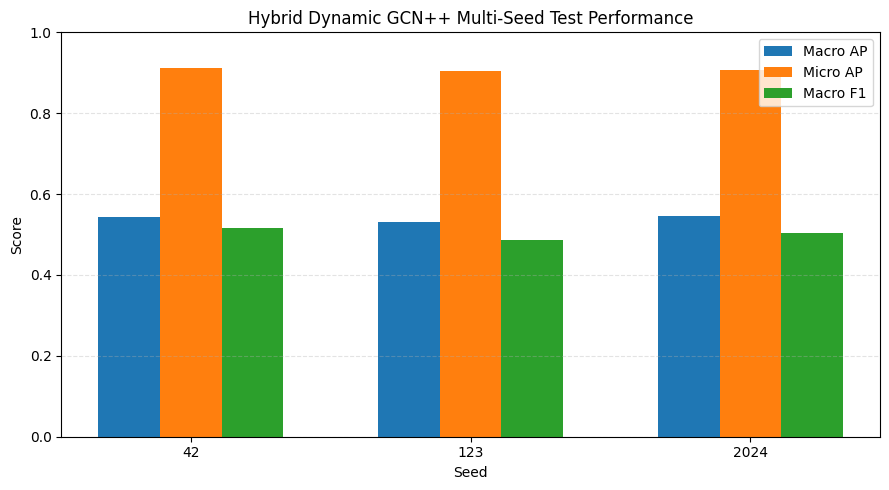

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/13_multiseed_seed_level_metrics.png


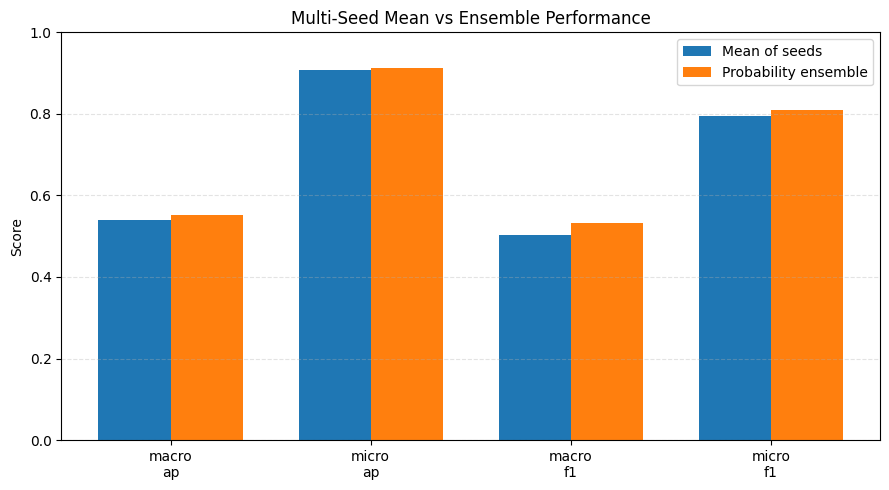

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/14_ensemble_vs_seed_mean.png


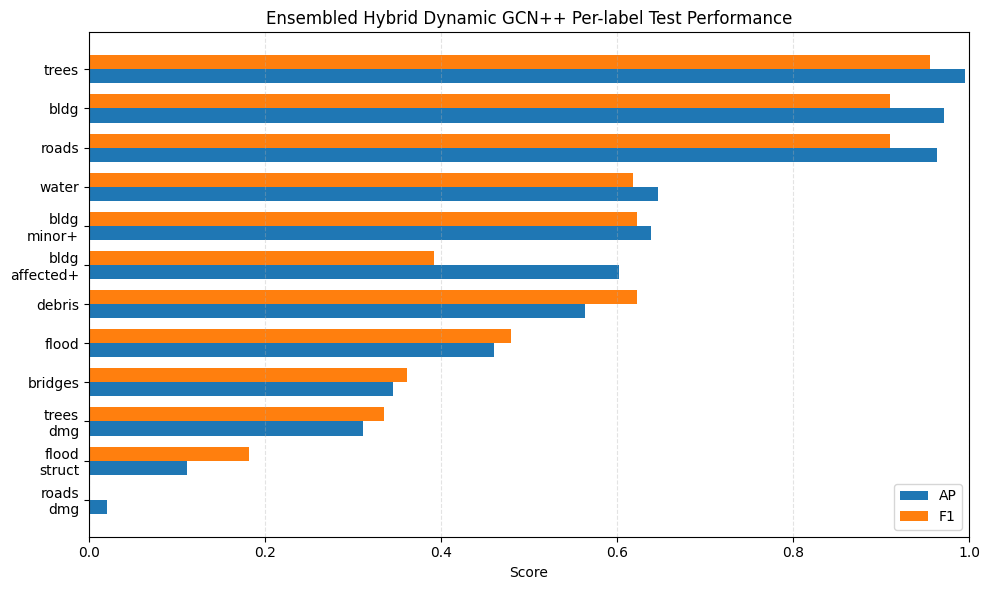

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/15_ensemble_per_label_ap_f1.png


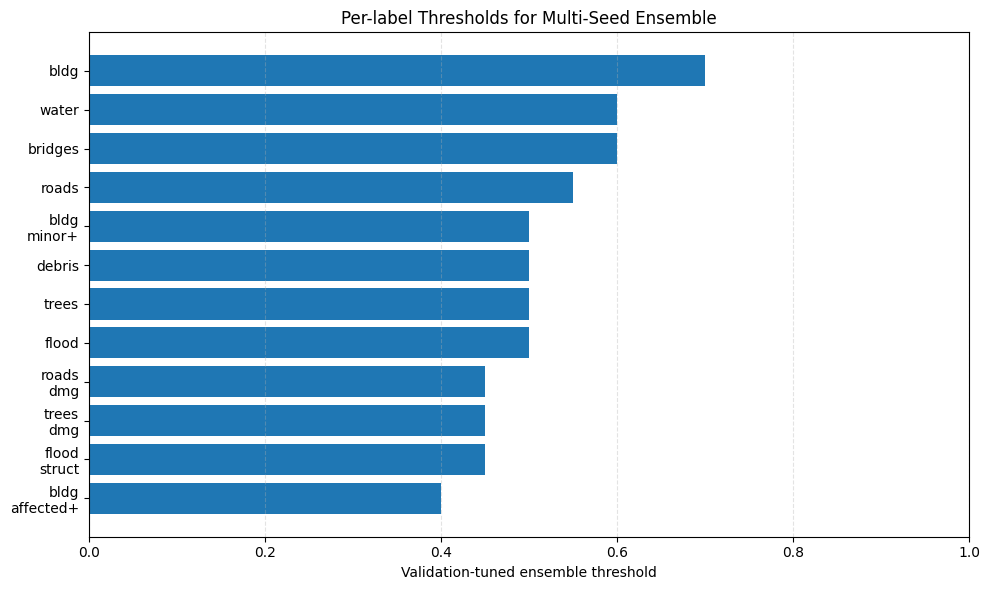

Saved figure: /kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/figures/16_ensemble_tuned_thresholds.png


In [15]:
# ============================================================
# 11A. Multi-Seed and Ensemble Result Plots
# ============================================================

# Use shared FIG_DIR under BASE_OUTPUT_DIR/figures.
FIG_DIR.mkdir(parents=True, exist_ok=True)

seed_summary_df = pd.read_csv(BASE_OUTPUT_DIR / "seed_level_summary.csv")
mean_std_df = pd.read_csv(BASE_OUTPUT_DIR / "mean_std_summary.csv")
ensemble_per_label_df = pd.read_csv(ENSEMBLE_DIR / "ensemble_test_per_label_metrics.csv")

# 1) Seed-level AP/F1 stability plot.
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(seed_summary_df))
width = 0.22
ax.bar(x - width, seed_summary_df["test_macro_ap"], width, label="Macro AP")
ax.bar(x, seed_summary_df["test_micro_ap"], width, label="Micro AP")
ax.bar(x + width, seed_summary_df["test_macro_f1"], width, label="Macro F1")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in seed_summary_df["seed"]])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Score")
ax.set_title("Hybrid Dynamic GCN++ Multi-Seed Test Performance")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend()
save_show(fig, "13_multiseed_seed_level_metrics.png")

# 2) Single-seed mean vs ensemble.
ensemble_row = {
    "model": "3-seed ensemble",
    "macro_ap": ensemble_test_metrics["macro_ap"],
    "micro_ap": ensemble_test_metrics["micro_ap"],
    "macro_f1": ensemble_test_metrics["macro_f1"],
    "micro_f1": ensemble_test_metrics["micro_f1"],
}
mean_row = {
    "model": "seed mean",
    "macro_ap": seed_summary_df["test_macro_ap"].mean(),
    "micro_ap": seed_summary_df["test_micro_ap"].mean(),
    "macro_f1": seed_summary_df["test_macro_f1"].mean(),
    "micro_f1": seed_summary_df["test_micro_f1"].mean(),
}
compare_df = pd.DataFrame([mean_row, ensemble_row])
compare_df.to_csv(BASE_OUTPUT_DIR / "ensemble_vs_seed_mean.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ["macro_ap", "micro_ap", "macro_f1", "micro_f1"]
x = np.arange(len(metrics))
ax.bar(x - 0.18, [mean_row[m] for m in metrics], width=0.36, label="Mean of seeds")
ax.bar(x + 0.18, [ensemble_row[m] for m in metrics], width=0.36, label="Probability ensemble")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in metrics])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Multi-Seed Mean vs Ensemble Performance")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend()
save_show(fig, "14_ensemble_vs_seed_mean.png")

# 3) Ensemble per-label AP/F1.
plot_df = ensemble_per_label_df.copy()
plot_df["label_short"] = plot_df["label"].map(_short_label)
plot_df = plot_df.sort_values("ap", ascending=True)
y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y_pos - 0.18, plot_df["ap"].fillna(0), height=0.36, label="AP")
ax.barh(y_pos + 0.18, plot_df["f1"].fillna(0), height=0.36, label="F1")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label_short"])
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_title("Ensembled Hybrid Dynamic GCN++ Per-label Test Performance")
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.legend()
save_show(fig, "15_ensemble_per_label_ap_f1.png")

# 4) Ensemble thresholds.
thr_df = ensemble_per_label_df.copy()
thr_df["label_short"] = thr_df["label"].map(_short_label)
thr_df = thr_df.sort_values("threshold", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.arange(len(thr_df)), thr_df["threshold"])
ax.set_yticks(np.arange(len(thr_df)))
ax.set_yticklabels(thr_df["label_short"])
ax.set_xlim(0, 1)
ax.set_xlabel("Validation-tuned ensemble threshold")
ax.set_title("Per-label Thresholds for Multi-Seed Ensemble")
ax.grid(axis="x", linestyle="--", alpha=0.35)
save_show(fig, "16_ensemble_tuned_thresholds.png")


In [16]:
# ============================================================
# 11B. Display Final Multi-Seed Summary Tables
# ============================================================

print("Seed-level summary:")
display(pd.read_csv(BASE_OUTPUT_DIR / "seed_level_summary.csv"))

print("Mean ± std summary:")
display(pd.read_csv(BASE_OUTPUT_DIR / "mean_std_summary.csv"))

print("Ensemble vs seed mean:")
display(pd.read_csv(BASE_OUTPUT_DIR / "ensemble_vs_seed_mean.csv"))

print("Ensemble per-label test metrics:")
display(pd.read_csv(ENSEMBLE_DIR / "ensemble_test_per_label_metrics.csv").sort_values("ap", ascending=False))


Seed-level summary:


,seed,best_val_macro_ap,best_val_macro_f1,selection_score,test_macro_ap,test_micro_ap,test_macro_f1,test_micro_f1,test_macro_precision,test_macro_recall,output_dir
0,42,0.708545,0.684917,0.845529,0.543957,0.912676,0.515997,0.795800,0.505360,0.587567,/kaggle/working/ladi_multiseed_runs/dynamic_gc...
1,123,0.697637,0.670925,0.831822,0.531523,0.904024,0.486996,0.780326,0.477719,0.594710,/kaggle/working/ladi_multiseed_runs/dynamic_gc...
2,2024,0.715729,0.686624,0.853054,0.545039,0.905705,0.504839,0.805563,0.509701,0.552967,/kaggle/working/ladi_multiseed_runs/dynamic_gc...


Mean ± std summary:


,metric,mean,std,min,max
0,best_val_macro_ap,0.707304,0.009110,0.697637,0.715729
1,best_val_macro_f1,0.680822,0.008614,0.670925,0.686624
2,test_macro_ap,0.540173,0.007511,0.531523,0.545039
3,test_micro_ap,0.907468,0.004588,0.904024,0.912676
4,test_macro_f1,0.502611,0.014629,0.486996,0.515997
5,test_micro_f1,0.793896,0.012726,0.780326,0.805563
6,test_macro_precision,0.497593,0.017348,0.477719,0.509701
7,test_macro_recall,0.578415,0.022326,0.552967,0.594710


Ensemble vs seed mean:


,model,macro_ap,micro_ap,macro_f1,micro_f1
0,seed mean,0.540173,0.907468,0.502611,0.793896
1,3-seed ensemble,0.552610,0.911601,0.532530,0.808352


Ensemble per-label test metrics:


,label,ap,f1,precision,recall,threshold
9,trees_any,0.995069,0.956118,0.964583,0.947799,0.50
1,buildings_any,0.971940,0.910326,0.941011,0.881579,0.70
7,roads_any,0.963519,0.910279,0.915173,0.905437,0.55
11,water_any,0.646717,0.617940,0.527660,0.745491,0.60
3,buildings_minor_or_greater,0.638158,0.622222,0.608696,0.636364,0.50
2,buildings_affected_or_greater,0.602404,0.392523,0.253012,0.875000,0.40
4,debris_any,0.563953,0.622951,0.612903,0.633333,0.50
5,flooding_any,0.460615,0.479592,0.412281,0.573171,0.50
0,bridges_any,0.345024,0.361111,0.684211,0.245283,0.60
10,trees_damage,0.311517,0.335484,0.257426,0.481481,0.45


## Notebook Completion Notes

This notebook trains the **Final Hybrid Dynamic GCN++ + EfficientNet-B0** model across multiple random seeds and saves:

```text
/kaggle/working/ladi_multiseed_runs/dynamic_gcn_efficientnet_b0_final_hybrid_p100_multiseed/
```

Important outputs:

```text
seed_level_summary.csv
mean_std_summary.csv
ensemble_vs_seed_mean.csv
seed_42/test_metrics.json
seed_123/test_metrics.json
seed_2024/test_metrics.json
ensemble/ensemble_test_metrics.json
ensemble/ensemble_test_predictions.csv
ensemble/ensemble_test_per_label_metrics.csv
figures/13_multiseed_seed_level_metrics.png
figures/14_ensemble_vs_seed_mean.png
figures/15_ensemble_per_label_ap_f1.png
figures/16_ensemble_tuned_thresholds.png
```

For a supervisor/report/paper, use:

- **mean ± standard deviation** to show reliability;
- **ensemble test metrics** to report the best probability-averaged multi-seed result;
- the original single-seed result only as a baseline comparison.
